# Exploratory Data Analysis
Visualizing the processed dataset.

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/processed/gtd_cleaned.csv')
outputs_dir = os.path.join('outputs')
os.makedirs(outputs_dir, exist_ok=True)
print(f'Dataset has {df.shape[0]:,} rows and {df.shape[1]} columns')

Dataset has 181,691 rows and 10 columns


### Temporal Trends: Attacks per Year

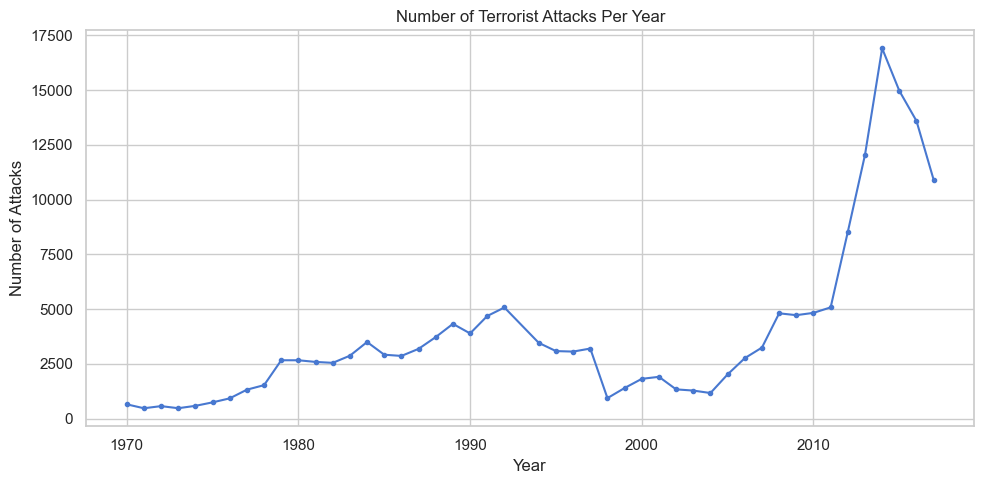

In [18]:
yearly = df['year'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
plt.plot(yearly.index, yearly.values, marker='o', linewidth=1.5, markersize=3)
plt.title('Number of Terrorist Attacks Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Attacks')
plt.tight_layout()
plt.savefig(os.path.join(outputs_dir, 'attacks_per_year.png'))
plt.show()

### Most Targeted Countries

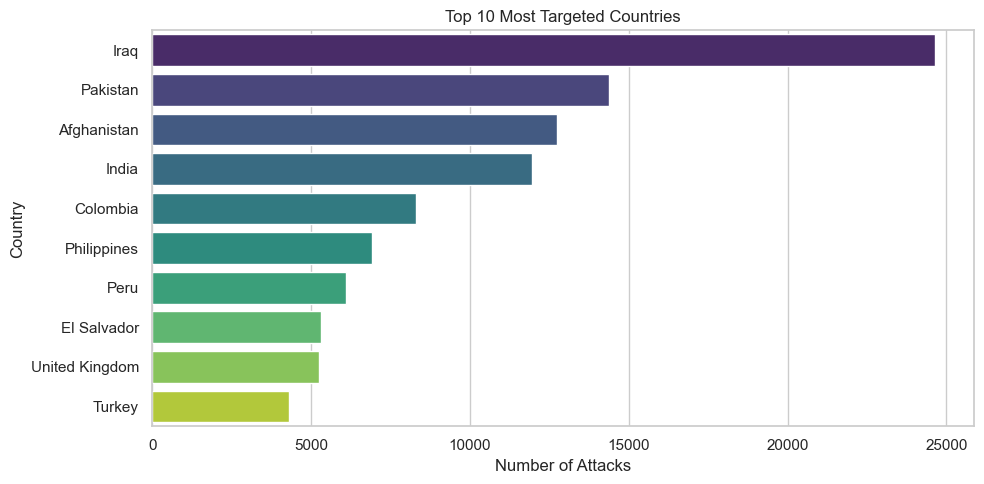

In [19]:
top_countries = df['country'].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')
plt.title('Top 10 Most Targeted Countries')
plt.xlabel('Number of Attacks')
plt.ylabel('Country')
plt.tight_layout()
plt.savefig(os.path.join(outputs_dir, 'top_countries.png'))
plt.show()

### Most Targeted Regions

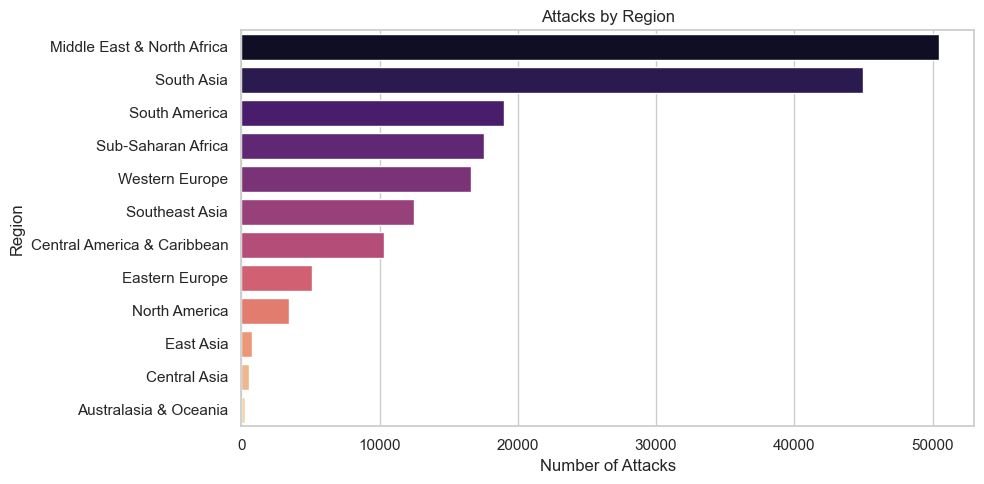

In [20]:
region_counts = df['region'].value_counts()

plt.figure(figsize=(10, 5))
sns.barplot(x=region_counts.values, y=region_counts.index, palette='magma')
plt.title('Attacks by Region')
plt.xlabel('Number of Attacks')
plt.ylabel('Region')
plt.tight_layout()
plt.savefig(os.path.join(outputs_dir, 'attacks_by_region.png'))
plt.show()

### Attack Types

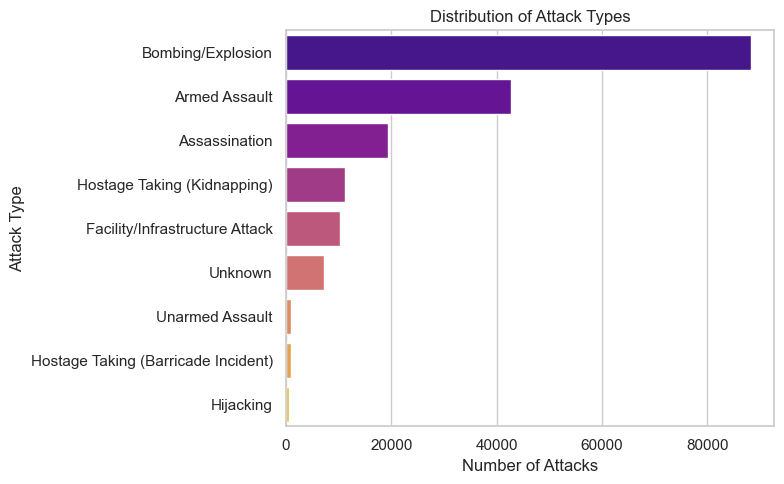

In [21]:
attack_counts = df['attack_type'].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(x=attack_counts.values, y=attack_counts.index, palette='plasma')
plt.title('Distribution of Attack Types')
plt.xlabel('Number of Attacks')
plt.ylabel('Attack Type')
plt.tight_layout()
plt.savefig(os.path.join(outputs_dir, 'attack_types.png'))
plt.show()

### Correlation Heatmap

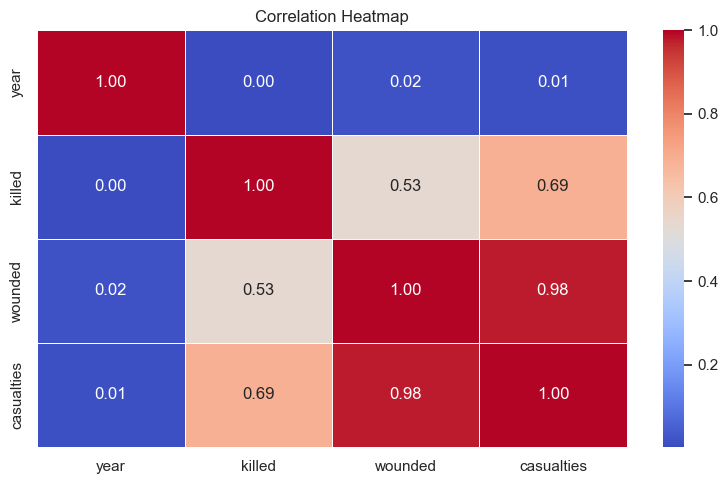

In [22]:
plt.figure(figsize=(8, 5))
numeric_cols = df[['year', 'killed', 'wounded', 'casualties']].dropna()
sns.heatmap(numeric_cols.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig(os.path.join(outputs_dir, 'correlation_heatmap.png'))
plt.show()

### Summary Stats

In [23]:
print(f"Total incidents         : {len(df):,}")
print(f"Year range              : {df['year'].min()} – {df['year'].max()}")
print(f"Unique countries        : {df['country'].nunique()}")
print(f"Unique regions          : {df['region'].nunique()}")
print(f"Total global casualties : {int(df['casualties'].sum()):,}")


Total incidents         : 181,691
Year range              : 1970 – 2017
Unique countries        : 205
Unique regions          : 12
Total global casualties : 872,892
